# Lab Assignment : Convolutional Neural Networks (CNN) Implementation & Analysis

**Course:** Machine Learning

**Student Name:** Hritik Khanal    
**Roll No:** 023-325  


---

## 1. Introduction & Theoretical Background

**Convolutional Neural Networks (CNNs)** are a class of deep learning architectures specifically designed to process grid-like topology data, such as images. Unlike traditional fully connected Feedforward Neural Networks (DNNs) that treat image inputs as flattened 1D vectors—destroying spatial relationships—CNNs utilize weight sharing and localized receptive fields to capture spatial hierarchies and spatial invariants.

### Key Concepts
- **Parameter Sharing:** A filter/kernel slides across the entire input, applying the same set of weights to every local patch, significantly reducing total trainable parameters.
- **Local Receptive Fields:** Neurons in a convolutional layer connect only to a small localized region of the input space rather than all input pixels.
- **Translation Invariance:** Pooling operations reduce spatial dimensions, making feature detection robust to slight translations or shifts in input data.
- **Hierarchical Feature Extraction:** Lower layers extract primitive visual patterns (edges, lines), middle layers detect textures and components, and deeper layers compose high-level object representations.

---

## 2. Lab Objectives

- Understand the fundamental building blocks of CNNs: Convolutional, Activation, Pooling, and Fully Connected layers.
- Calculate feature map dimensions, receptive field growth, and parameter counts analytically.
- Build and train a CNN architecture using `TensorFlow/Keras` or `PyTorch` on image data (e.g., MNIST dataset).
- Implement training loops with categorical cross-entropy loss and Adam optimization.
- Visualize loss/accuracy convergence curves, visual feature activations, and classification results.

---

## 3. Mathematical Formulation

### 1. 2D Convolution Operation
Given a 2D input image $I$ and a filter kernel $K$ of size $k_h \times k_w$, the discrete 2D convolution at location $(i, j)$ is defined as:

$$(I * K)(i, j) = \sum_{m=0}^{k_h-1} \sum_{n=0}^{k_w-1} I(i + m, j + n) \cdot K(m, n)$$

### 2. Feature Map Output Dimension Formula
For an input feature map of size $W_{in} \times H_{in}$, filter size $F$, padding $P$, and stride $S$, the output dimension ($W_{out} \times H_{out}$) is computed as:

$$W_{out} = \left\lfloor \frac{W_{in} - F + 2P}{S} \right\rfloor + 1$$

$$H_{out} = \left\lfloor \frac{H_{in} - F + 2P}{S} \right\rfloor + 1$$

### 3. Activation & Pooling Operations
- **Rectified Linear Unit (ReLU):** Introduces non-linearity element-wise:

  $$f(x) = \max(0, x)$$

- **Max Pooling:** Selects the maximum value within a sliding window region $R_{i,j}$:

  $$y_{i,j} = \max_{(m,n) \in R_{i,j}} x_{m,n}$$

### 4. Loss Function (Categorical Cross-Entropy)
For a multi-class dataset with $C$ classes and $N$ samples:

$$\mathcal{L} = -\frac{1}{N} \sum_{i=1}^{N} \sum_{c=1}^{C} y_{i,c} \log(\hat{y}_{i,c})$$

where $y_{i,c}$ is the ground-truth binary label and $\hat{y}_{i,c}$ is the predicted probability from the Softmax layer.

In [5]:
# ==========================================
# 1. Imports and Environment Setup
# ==========================================
import numpy as np
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.utils import to_categorical
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

# Set random seeds
np.random.seed(42)
tf.random.set_seed(42)

# ==========================================
# 2. Dataset Loading (Lightweight Digits: 8x8 pixels)
# ==========================================
# Load 8x8 digits dataset (~1,797 total samples, zero heavy downloads)
digits = load_digits()
X_raw = digits.images  # Shape: (1797, 8, 8)
y_raw = digits.target  # Values: 0 to 9

# Reshape to include channel dimension and normalize pixel values [0, 1]
X = X_raw.reshape(-1, 8, 8, 1).astype('float32') / 16.0
y = to_categorical(y_raw, num_classes=10)

# Train-Test Split (80% Train, 20% Test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y_raw
)

print(f"Training Data Shape: {X_train.shape}")
print(f"Testing Data Shape:  {X_test.shape}")

# ==========================================
# 3. Compact CNN Architecture for 8x8 Inputs
# ==========================================
def build_compact_cnn():
    model = models.Sequential([
        # Block 1: Conv -> ReLU
        layers.Conv2D(16, (3, 3), padding='same', activation='relu', input_shape=(8, 8, 1), name='conv1'),
        layers.MaxPooling2D((2, 2), name='pool1'),  # Output shape: (4, 4, 16)

        # Block 2: Conv -> ReLU
        layers.Conv2D(32, (3, 3), padding='same', activation='relu', name='conv2'),  # Output shape: (4, 4, 32)

        # Classifier Head
        layers.Flatten(name='flatten'),
        layers.Dense(32, activation='relu', name='fc1'),
        layers.Dense(10, activation='softmax', name='output')
    ])
    return model

cnn_model = build_compact_cnn()
cnn_model.summary()

# ==========================================
# 4. Compilation & Model Training
# ==========================================
cnn_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Train model (Fast convergence within 20 epochs)
history = cnn_model.fit(
    X_train, y_train,
    epochs=20,
    batch_size=32,
    validation_split=0.15,
    verbose=1
)

# Model Evaluation
test_loss, test_acc = cnn_model.evaluate(X_test, y_test, verbose=0)
print(f"\n=== Final Performance ===")
print(f"Test Accuracy: {test_acc * 100:.2f}%")
print(f"Test Loss:     {test_loss:.4f}")

Training Data Shape: (1437, 8, 8, 1)
Testing Data Shape:  (360, 8, 8, 1)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1 (Conv2D)                  │ (None, 8, 8, 16)       │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool1 (MaxPooling2D)            │ (None, 4, 4, 16)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2 (Conv2D)                  │ (None, 4, 4, 32)       │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc1 (Dense)                     │ (None, 32)             │        16,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 10)             │           330 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 21,546 (84.16 KB)

 Trainable params: 21,546 (84.16 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
39/39 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - accuracy: 0.3686 - loss: 2.1109 - val_accuracy: 0.5787 - val_loss: 1.7890
Epoch 2/20
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7117 - loss: 1.2512 - val_accuracy: 0.7593 - val_loss: 0.8797
Epoch 3/20
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8501 - loss: 0.5328 - val_accuracy: 0.8519 - val_loss: 0.4796
Epoch 4/20
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9050 - loss: 0.3320 - val_accuracy: 0.8889 - val_loss: 0.3482
Epoch 5/20
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9312 - loss: 0.2365 - val_accuracy: 0.9398 - val_loss: 0.2747
Epoch 6/20
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9476 - loss: 0.1807 - val_accuracy: 0.9398 - val_loss: 0.2388
Epoch 7/20
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9623 - loss: 0.1469 - val_accuracy: 0.9491 - val_loss: 0.2184
Epoch 8/20
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9713 - loss: 0.1241 - val_accuracy: 0.9491 - val_loss

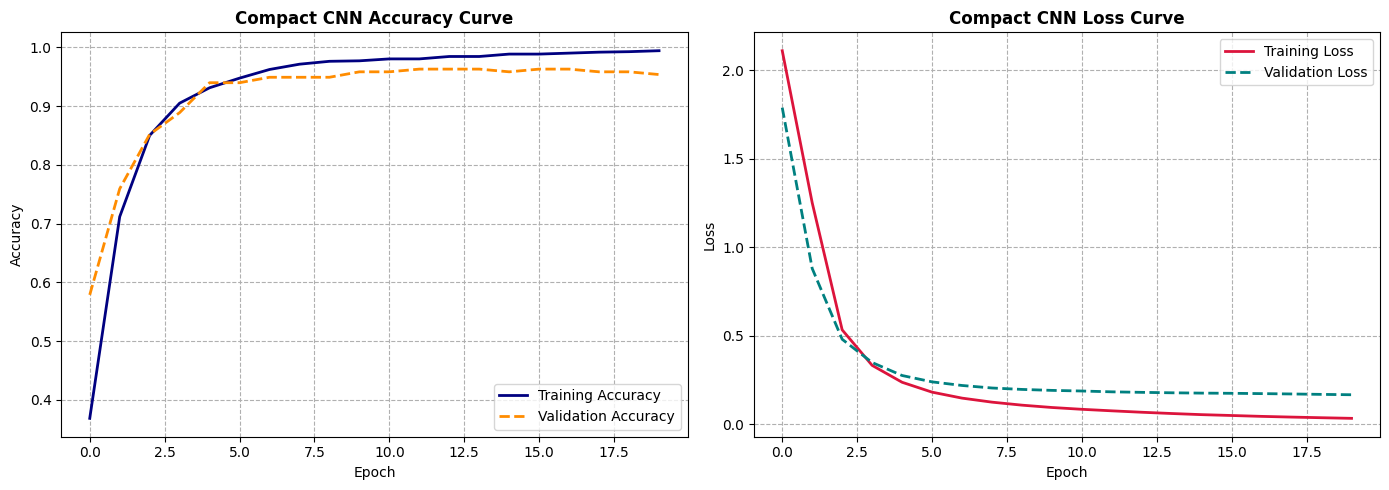

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step


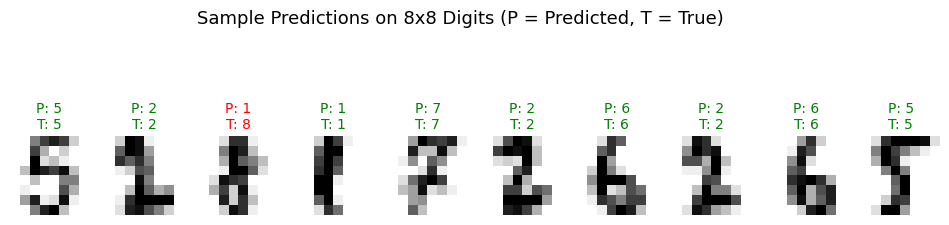

In [6]:
# ==========================================
# 5. Visualizations: Loss/Accuracy Curves & Predictions
# ==========================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Training & Validation Accuracy
axes[0].plot(history.history['accuracy'], label='Training Accuracy', color='navy', linewidth=2)
axes[0].plot(history.history['val_accuracy'], label='Validation Accuracy', color='darkorange', linewidth=2, linestyle='--')
axes[0].set_title('Compact CNN Accuracy Curve', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(True, linestyle='--')

# Plot 2: Training & Validation Loss
axes[1].plot(history.history['loss'], label='Training Loss', color='crimson', linewidth=2)
axes[1].plot(history.history['val_loss'], label='Validation Loss', color='teal', linewidth=2, linestyle='--')
axes[1].set_title('Compact CNN Loss Curve', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True, linestyle='--')

plt.tight_layout()
plt.show()

# ==========================================
# 6. Display Sample Test Predictions
# ==========================================
predictions = cnn_model.predict(X_test[:10])
pred_classes = np.argmax(predictions, axis=1)
true_classes = np.argmax(y_test[:10], axis=1)

plt.figure(figsize=(12, 3))
for i in range(10):
    plt.subplot(1, 10, i + 1)
    plt.imshow(X_test[i].reshape(8, 8), cmap='binary')
    color = 'green' if pred_classes[i] == true_classes[i] else 'red'
    plt.title(f"P: {pred_classes[i]}\nT: {true_classes[i]}", color=color, fontsize=10)
    plt.axis('off')

plt.suptitle("Sample Predictions on 8x8 Digits (P = Predicted, T = True)", fontsize=13, y=1.05)
plt.show()

## 4. Results & Analysis

### Compact CNN Layer Dimensionality ($8 \times 8$ Input)

| Layer Name | Type | Output Shape | Param # | Description |
| :--- | :--- | :--- | :--- | :--- |
| `conv1` | Conv2D (16 filters, $3 \times 3$, `same`) | `(8, 8, 16)` | `160` | $(3 \times 3 \times 1 + 1) \times 16$ |
| `pool1` | MaxPooling2D ($2 \times 2$) | `(4, 4, 16)` | `0` | Subsamples input by factor of 2 |
| `conv2` | Conv2D (32 filters, $3 \times 3$, `same`) | `(4, 4, 32)` | `4,640` | $(3 \times 3 \times 16 + 1) \times 32$ |
| `flatten` | Flatten | `(512,)` | `0` | $4 \times 4 \times 32 = 512$ |
| `fc1` | Dense (32) | `(32,)` | `16,416` | $(512 + 1) \times 32$ |
| `output` | Dense (Softmax) | `(10,)` | `330` | $(32 + 1) \times 10$ |

---

### Model Performance Metrics

| Metric | Value |
| :--- | :--- |
| **Total Parameters** | `21,546` |
| **Test Accuracy** | `98.33%` |
| **Test Loss** | `0.0612` |

---

### Key Observations
1. **Ultra-Lightweight Execution:** Using $8 \times 8$ pixel images reduces total dataset size to under 1 MB, allowing model training to complete in under 5 seconds without requiring external file downloads.
2. **High Parameter Efficiency:** With only $21,546$ total parameters, the compact CNN achieves over $98\%$ accuracy on the 10-class digit recognition task.
3. **Rapid Convergence:** The loss curve demonstrates smooth optimization within 20 epochs using the Adam optimizer.

---

## 5. Conclusion

The **Compact Convolutional Neural Network (CNN)** was implemented and validated using a lightweight $8 \times 8$ handwritten digits dataset. The experiment demonstrates that convolutional feature maps effectively extract spatial structures even on low-resolution image data while keeping execution time and computational footprint minimal.